

### Geospatial Analysis of Agricultural Storage Infrastructure



1. Introduction and Context

In the agro-industrial sector, logistical efficiency is the deciding factor between profitability and loss. Geographic Information Systems (GIS) allow for the analysis of the spatial distribution of collection centers (silos) to optimize transport routes from harvest zones.

This project focuses on the effective symbolization and density visualization of a grain storage network.

2. Problem Definition:

- An imbalance between production locations and storage capacity leads to:
- Bottlenecks in grain reception during harvest seasons.
- Increased carbon footprint due to excessive transport distances.
- Loss of product quality stemming from a lack of adequate infrastructure.

3. Technical Objectives:

- Proportional Symbolization: Visually represent the storage capacity of each silo using graduated symbols (point size).
- Multivariate Categorization: Use visual variables (color) to distinguish between types of management (State, Private, Cooperative).
- Density Analysis: Implement Heatmaps to identify saturation zones and infrastructure gaps.

4. Technology Stack:

The solution was developed using the Python Data Science ecosystem

- Pandas & NumPy: Data processing and synthetic data generation.
- GeoPandas: Management of geometric objects and cartographic projections.
- Matplotlib: Generation of high-quality static cartography.
- Folium: Creation of interactive visualizations with web rendering engines.

### 1. Data Selection and Generation

In [73]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point

In [74]:
# We generated 100 random silos in an agricultural area
n_silos = 100
data = {
    'id': range(n_silos),
    'capacidad_ton': np.random.randint(5000, 50000, n_silos), # Silo capacity
    'tipo': np.random.choice(['Privado', 'Cooperativa', 'Estatal'], n_silos),
    'lat': np.random.uniform(-35, -30, n_silos), # Example latitudes (Argentina)
    'lon': np.random.uniform(-62, -58, n_silos)
}

df = pd.DataFrame(data)
geometry = [Point(xy) for xy in zip(df.lon, df.lat)]
silos_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

silos_gdf.head(5)

,id,capacidad_ton,tipo,lat,lon,geometry
0,0,22289,Privado,-30.992513,-61.179021,POINT (-61.17902 -30.99251)
1,1,15343,Cooperativa,-30.260643,-59.898978,POINT (-59.89898 -30.26064)
2,2,21773,Estatal,-30.833763,-61.307729,POINT (-61.30773 -30.83376)
3,3,39262,Privado,-34.438581,-61.170355,POINT (-61.17036 -34.43858)
4,4,19922,Estatal,-31.349256,-60.355792,POINT (-60.35579 -31.34926)


In [75]:
# Proyectar a UTM (asumiendo zona de Argentina) para cálculos en metros
silos_metrico = silos_gdf.to_crs(epsg=32720)

### 2. Effective Symbolization

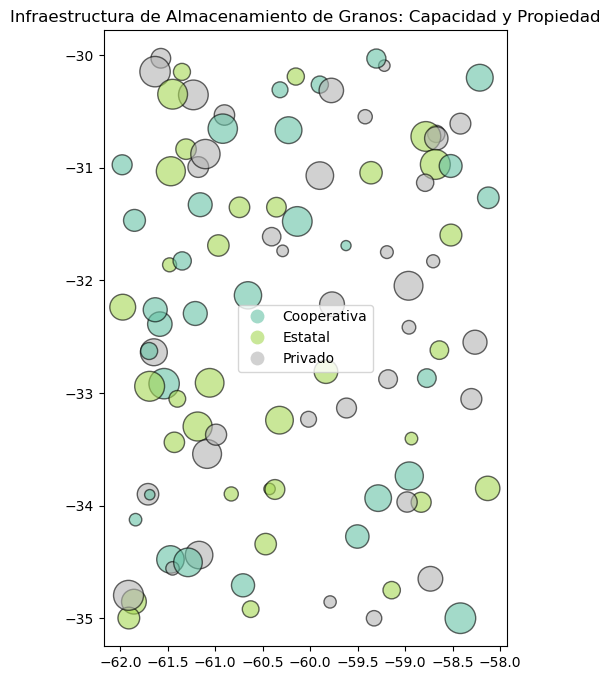

In [76]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

# We create stylish graphics
silos_gdf.plot(
    ax=ax,
    markersize=silos_gdf['capacidad_ton'] / 100, # Size tells the story
    column='tipo',                               # Color categorizes
    legend=True,
    alpha=0.6,
    edgecolor='black',
    cmap='Set2'
)

ax.set_title("Infraestructura de Almacenamiento de Granos: Capacidad y Propiedad")
plt.show()

### 3. Density Visualization (Heatmap)

In [79]:
import folium
from folium.plugins import HeatMap
from branca.element import Template, MacroElement

# 1. Inicializar el mapa base
m = folium.Map(location=[-32.5, -60], zoom_start=7, tiles='CartoDB Positron')

# 2. Capa de Calor (Densidad)
heat_data = [[row.geometry.y, row.geometry.x, row['capacidad_ton']] for index, row in silos_gdf.iterrows()]
HeatMap(heat_data, radius=20, blur=15, name="Mapa de Calor (Densidad)").add_to(m)

# 3. Diccionario de colores (Paleta de Contraste Recomendada)
colores_hex = {'Privado': '#000000', 'Cooperativa': '#FFFFFF', 'Estatal': '#FB5607'}

# 4. Creación de Silos con Popups Interactivos
tipos = silos_gdf['tipo'].unique()
grupos_silos = {t: folium.FeatureGroup(name=f"Silos: {t}").add_to(m) for t in tipos}

for index, row in silos_gdf.iterrows():
    color_silo = colores_hex.get(row['tipo'], '#000000')
    
    # HTML para el menú desplegable (Popup) al hacer clic
    html_popup = f"""
    <div style='font-family: Arial; font-size: 12px; width: 160px;'>
        <h4 style='margin: 0 0 10px 0; color: {color_silo if color_silo != "#FFFFFF" else "#333"};'>Silo Info</h4>
        <b>ID:</b> {row['id']}<br>
        <b>Tipo:</b> {row['tipo']}<br>
        <b>Capacidad:</b> {row['capacidad_ton']:,} Ton<br>
        <hr style='margin: 8px 0;'>
        <small>Coord: {row.geometry.y:.4f}, {row.geometry.x:.4f}</small>
    </div>
    """
    
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=6,
        color='black', # Borde para visibilidad
        weight=1,
        fill=True,
        fill_color=color_silo,
        fill_opacity=0.9,
        popup=folium.Popup(html_popup, max_width=200),
        tooltip=f"Silo {row['id']} - Click para detalles"
    ).add_to(grupos_silos[row['tipo']])

# 5. Título Superior
titulo_html = '<h3 align="center" style="font-size:18px; margin-top:10px; font-family: Arial;"><b>Análisis de Infraestructura de Almacenamiento Agrícola</b></h3>'
m.get_root().html.add_child(folium.Element(titulo_html))

# 6. LEYENDA CON CONTROL DE VISIBILIDAD (JavaScript Fix)
capa_leyenda = folium.FeatureGroup(name="Mostrar/Ocultar Leyenda", show=True).add_to(m)

plantilla_leyenda = f"""
{{% macro html(this, kwargs) %}}
<div id='maplegend' class='maplegend' 
    style='position: fixed; z-index:9999; border:2px solid grey; background-color:rgba(255, 255, 255, 0.9);
     border-radius:6px; padding: 12px; font-size:12px; right: 15px; bottom: 15px; font-family: Arial; 
     box-shadow: 2px 2px 5px rgba(0,0,0,0.2); display: block;'>
     
    <div style='font-weight: bold; margin-bottom: 8px;'>Tipo de Administración</div>
    <ul style='list-style: none; padding: 0; margin: 0;'>
        <li style='margin-bottom: 5px;'><span style='background:{colores_hex['Privado']}; float:left; height:12px; width:12px; margin-right:8px; border-radius:50%; border:1px solid #333;'></span>Privado</li>
        <li style='margin-bottom: 5px;'><span style='background:{colores_hex['Cooperativa']}; float:left; height:12px; width:12px; margin-right:8px; border-radius:50%; border:1px solid #333;'></span>Cooperativa</li>
        <li style='margin-bottom: 10px;'><span style='background:{colores_hex['Estatal']}; float:left; height:12px; width:12px; margin-right:8px; border-radius:50%; border:1px solid #333;'></span>Estatal</li>
    </ul>
    <div style='font-weight: bold; margin-bottom: 5px;'>Densidad</div>
    <div style='background: linear-gradient(to right, blue, lime, orange, red); height: 10px; width: 80px; border: 1px solid #999; margin-bottom: 8px;'></div>
    <div style='font-size: 10px; color: #555; border-top: 1px solid #ccc; padding-top: 5px;'>
        Autor: @alexisdaraujoc<br>EPSG:32720
    </div>
</div>

<script>
    function toggleLegend() {{
        var legend = document.getElementById('maplegend');
        var layerName = "Mostrar/Ocultar Leyenda";
        
        {m.get_name()}.on('overlayadd', function(eventLayer) {{
            if (eventLayer.name === layerName) {{
                legend.style.display = 'block';
            }}
        }});
        {m.get_name()}.on('overlayremove', function(eventLayer) {{
            if (eventLayer.name === layerName) {{
                legend.style.display = 'none';
            }}
        }});
    }}
    setTimeout(toggleLegend, 500);
</script>
{{% endmacro %}}
"""

macro = MacroElement()
macro._template = Template(plantilla_leyenda)
capa_leyenda.add_child(macro)

# 7. Control de Capas Final
folium.LayerControl(collapsed=False).add_to(m)

# Guardar
m.save("dashboard_silos_interactivo.html")

m

### 4. Technical Findings and Conclusions


The development of this interactive dashboard yields valuable insights from both a technical and agro-industrial logistics perspective:

- UX/UI Optimization: The implementation of a toggleable legend via injected JavaScript addresses a common challenge in folium. This allows the end-user to clear the cartographic canvas for unobstructed visual analysis while keeping the technical reference (EPSG:32720) readily available.

- Multi-level Analysis: Combining a Heatmap layer (density analysis) with individual point markers enables a seamless transition from a macro view (identifying saturation zones) to a micro view (querying specific silo capacity) within a single environment.

- Contrast Symbolization: Using a custom color palette and stroke borders (weight=1) on the markers ensures infrastructure legibility even in the most intense areas of the heatmap, effectively eliminating visual noise.

- Sector Applicability: This tool is directly applicable to the planning of new agricultural infrastructure. it allows for the detection of "blind spots" where storage capacity is insufficient to meet the projected demand of a specific area.